# 1. Download simulation data from Planck archive


## 1.1 CMB signal realizations
Source: Planck Legacy Archive: https://pla.esac.esa.int/#maps > maps > Simulations tab

From the Planck Archive website (under the Simulations tab), the Filtered Eclectic Beam Convolved Observed Patch (febecop) simulations contain CMB data for the following frequency bands:   [030, 044, 070, 100, 143, 217, 353] GHz

For the frequency bands 545 GHz and 857 GHz, these simulations can be downloaded from a different URL (Provided)

Official download instructions: https://wiki.cosmos.esa.int/planck-legacy-archive/index.php/Simulation_data#CMB_realizations

In [14]:
!pip install skyclean --upgrade
# import skyclean as sc
# from skyclean import download_cmb_realizations

In [1]:
import skyclean as sc


### Reference: Skyclean download_cmb_realizations fucntion


In [2]:
import os
import requests
def download_cmb_realizations(directory, frequencies, realizations, url_template, filename_template, realization_digit):
    """
    Downloads Cosmic Microwave Background (CMB) realizations for specified frequencies and realizations.

    This function will download files from a specified URL template, format them according to the frequency and 
    realization number, and save them in the specified directory. If the file already exists, it will skip the download.

    Parameters:
    directory (str): The directory where files will be saved.
    frequencies (list of str): A list of frequency identifiers to download.
    realizations (range or list of int): A range or list of realization numbers to download.
    url_template (str): The URL template that will be formatted with the frequency and realization.
    filename_template (str): The template for the filename that will be used when saving the files.
    realization_digit (int): The number of digits to use for formatting the realization number (e.g., 4 digits for "0001").

    Returns:
    None

    Example:# 
    directory = 'CMB_realizations'
    frequencies = ["030", "044", "070", "100", "143", "217", "353"]  # Example frequencies
    realizations = range(30)  # Example: 30 realizations from 0 to 29
    url_template = "http://pla.esac.esa.int/pla/aio/product-action?SIMULATED_MAP.FILE_ID=febecop_ffp10_lensed_scl_cmb_{frequency}_mc_{realization}.fits"
    filename_template = "febecop_ffp10_lensed_scl_cmb_{frequency}_mc_{realization}.fits"
    realization_digit = 4 
    download_cmb_realizations(directory, frequencies, realizations, url_template, filename_template, realization_digit)
    
    # Note: 545 and 857 GHz have different urls
    frequencies = [ "545", "857"]  # Example frequencies
    filename_template = "symbeam_ffp10_lensed_scl_cmb_{frequency}_mc_{realization}.fits"
    url_template = "http://pla.esac.esa.int/pla/aio/product-action?SIMULATED_MAP.FILE_ID=symbeam_ffp10_lensed_scl_cmb_{frequency}_mc_{realization}.fits"
    download_cmb_realizations(directory, frequencies, realizations, url_template, filename_template, realization_digit)
    
    """

    # Ensure the directory exists
    if not os.path.exists(directory):
        os.makedirs(directory)

    # Loop through each frequency and realization
    for realization in realizations:
        for frequency in frequencies: 
            realization_str = str(realization).zfill(realization_digit)
            filename = filename_template.format(frequency=frequency, realization=realization_str)
            file_path = os.path.join(directory, filename)

            # Check if the file already exists
            if os.path.exists(file_path):
                print(f"File {filename} already exists. Skipping download.")
                continue

            # Format the URL with the current frequency and realization
            url = url_template.format(frequency=frequency, realization=realization_str)

            # Send a GET request to the URL
            response = requests.get(url)

            # Check if the request was successful
            if response.status_code == 200:
                # Open the file in binary write mode and write the content
                with open(file_path, 'wb') as f:
                    f.write(response.content)
                print(f"Downloaded {file_path}")
            else:
                print(f"Failed to download data for frequency {frequency} and realization {realization_str}. Status code: {response.status_code}")


In [6]:
# Example usage: download_cmb_realizations
# Febecop FFP10 lensed CMB realizations

store_directory = 'CMB_realizations'
frequencies = ["030", "044", "070", "100", "143", "217", "353"]  # Example frequencies
reallization = 5
realizations = range(reallization)  # Example: 10 realizations from 0 to 9
url_template = "http://pla.esac.esa.int/pla/aio/product-action?SIMULATED_MAP.FILE_ID=febecop_ffp10_lensed_scl_cmb_{frequency}_mc_{realization}.fits"
store_filename_template = "febecop_ffp10_lensed_scl_cmb_{frequency}_mc_{realization}.fits"
realization_digit = 4 
sc.download_cmb_realizations(store_directory, frequencies, realizations, url_template, store_filename_template, realization_digit)

special_path_frequencies = [ "545", "857"]  # Example frequencies
# for simplied processing (the downloaded fits files are name as febecop, symbeam is the original code)
store_filename_template = "febecop_ffp10_lensed_scl_cmb_{frequency}_mc_{realization}.fits"
url_template = "http://pla.esac.esa.int/pla/aio/product-action?SIMULATED_MAP.FILE_ID=symbeam_ffp10_lensed_scl_cmb_{frequency}_mc_{realization}.fits"
# sc.download_cmb_realizations(store_directory, special_path_frequencies, realizations, url_template, store_filename_template, realization_digit)
sc.download_cmb_realizations(store_directory, special_path_frequencies, realizations, url_template, store_filename_template, realization_digit)


Failed to download data for frequency 030 and realization 0000. Status code: 404
Failed to download data for frequency 044 and realization 0000. Status code: 404
Failed to download data for frequency 070 and realization 0000. Status code: 404
Failed to download data for frequency 100 and realization 0000. Status code: 404
Failed to download data for frequency 143 and realization 0000. Status code: 404
Failed to download data for frequency 217 and realization 0000. Status code: 404
Failed to download data for frequency 353 and realization 0000. Status code: 404
Failed to download data for frequency 030 and realization 0001. Status code: 404
Failed to download data for frequency 044 and realization 0001. Status code: 404
Failed to download data for frequency 070 and realization 0001. Status code: 404


KeyboardInterrupt: 

## 1.2 Download synchrotron realizations

Only 1 synchrotron realziation for each frequency. For downloading other type of foreground emissions please refer to
 https://wiki.cosmos.esa.int/planck-legacy-archive/index.php/Simulation_data#The_Planck_Sky_Model

In [19]:
# synchrotron
store_directory = 'CMB_realizations'
frequencies = ["030", "044", "070", "100", "143", "217", "353", "545", "857"]  # Example frequencies
realizations = range(1)  
filename_template = "COM_SimMap_synchrotron-ffp10-skyinbands-{frequency}_2048_R3.00_full.fits"
url_template = "http://pla.esac.esa.int/pla/aio/product-action?SIMULATED_MAP.FILE_ID=COM_SimMap_synchrotron-ffp10-skyinbands-{frequency}_2048_R3.00_full.fits"
realization_digit = 4 
sc.download_cmb_realizations(store_directory, frequencies, realizations, url_template, filename_template, realization_digit)


File COM_SimMap_synchrotron-ffp10-skyinbands-030_2048_R3.00_full.fits already exists. Skipping download.
File COM_SimMap_synchrotron-ffp10-skyinbands-044_2048_R3.00_full.fits already exists. Skipping download.
File COM_SimMap_synchrotron-ffp10-skyinbands-070_2048_R3.00_full.fits already exists. Skipping download.
File COM_SimMap_synchrotron-ffp10-skyinbands-100_2048_R3.00_full.fits already exists. Skipping download.
File COM_SimMap_synchrotron-ffp10-skyinbands-143_2048_R3.00_full.fits already exists. Skipping download.
File COM_SimMap_synchrotron-ffp10-skyinbands-217_2048_R3.00_full.fits already exists. Skipping download.
File COM_SimMap_synchrotron-ffp10-skyinbands-353_2048_R3.00_full.fits already exists. Skipping download.
File COM_SimMap_synchrotron-ffp10-skyinbands-545_2048_R3.00_full.fits already exists. Skipping download.
File COM_SimMap_synchrotron-ffp10-skyinbands-857_2048_R3.00_full.fits already exists. Skipping download.


## 1.3 Download noise realizations

Noise realizations have 5 digits.

Official instructions: https://wiki.cosmos.esa.int/planck-legacy-archive/index.php/Simulation_data#Noise_and_instrumental_effect_residual_maps

In [20]:
# Noise
store_directory = 'CMB_realizations'
frequencies = ["030", "044", "070", "100", "143", "217", "353", "545", "857"]  # Example frequencies
realizations = range(reallization)
realization_digit = 5
filename_template = "ffp10_noise_{frequency}_full_map_mc_{realization}.fits"
url_template = "http://pla.esac.esa.int/pla/aio/product-action?SIMULATED_MAP.FILE_ID=ffp10_noise_{frequency}_full_map_mc_{realization}.fits"

sc.download_cmb_realizations(store_directory, frequencies, realizations, url_template, filename_template,realization_digit)

File ffp10_noise_030_full_map_mc_00000.fits already exists. Skipping download.
File ffp10_noise_044_full_map_mc_00000.fits already exists. Skipping download.
File ffp10_noise_070_full_map_mc_00000.fits already exists. Skipping download.
File ffp10_noise_100_full_map_mc_00000.fits already exists. Skipping download.
File ffp10_noise_143_full_map_mc_00000.fits already exists. Skipping download.
File ffp10_noise_217_full_map_mc_00000.fits already exists. Skipping download.
File ffp10_noise_353_full_map_mc_00000.fits already exists. Skipping download.
File ffp10_noise_545_full_map_mc_00000.fits already exists. Skipping download.
File ffp10_noise_857_full_map_mc_00000.fits already exists. Skipping download.


Download Beams (already downloaded)

In [ ]:
# https://irsa.ipac.caltech.edu/data/Planck/release_3/ancillary-data/HFI_Products.html
# HFI beams
# HFI_RIMO_BEAMS_R3.01.tar.gz

Temp: Create CMB realisation

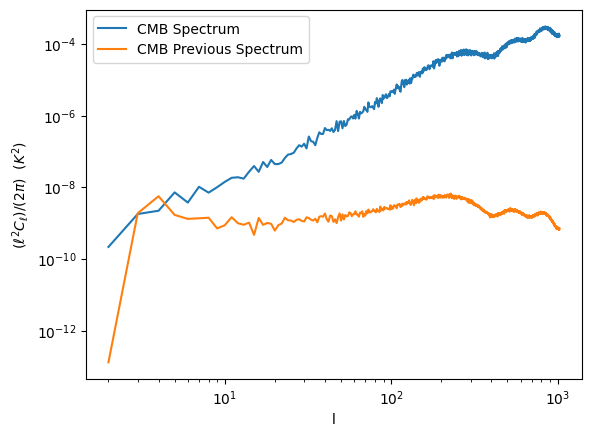

setting the output map dtype to [dtype('float64')]


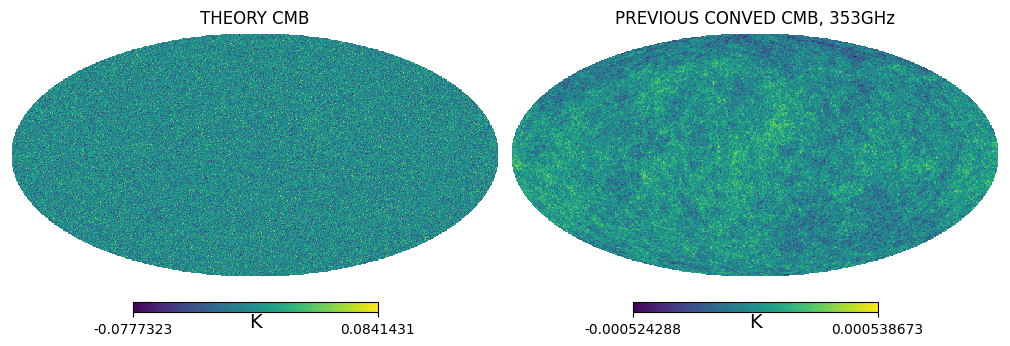

In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
# PLANCK C_ell
l, cl, cl_plus, cl_minus = np.loadtxt("cmb_spectrum.txt").transpose()
l = l[:1024]
cl = cl[:1024]
cl *= 1E-12 # convert to K 
nside = 2048
cmb_previous = hp.read_map("data/CMB_realizations/febecop_ffp10_lensed_scl_cmb_353_mc_0000.fits") 
cmb_cl = hp.anafast(cmb_previous, lmax=1023)
plt.plot(l, (l*(l+1) * cl)/(2*np.pi), label='CMB Spectrum')
plt.plot(l, (l*(l+1) * cmb_cl)/(2*np.pi), label='CMB Previous Spectrum')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('l')
plt.ylabel(r'$(\ell^2 C_\ell)/(2\pi)$  ($K^2$)')
plt.show()
cmb_map = hp.synfast(cl, nside=nside) 
fig = plt.figure(figsize=(10, 5))
hp.mollview(spectrum, title='THEORY CMB', cmap='viridis', unit = 'K', fig = fig.number, sub=(1,2,1))
hp.write_map("data/CMB_realizations/cmb_spectrum.fits", spectrum, overwrite=True)
hp.mollview(cmb_previous, title='PREVIOUS CONVED CMB, 353GHz', unit = 'K', fig = fig.number, sub=(1,2,2))